# 🔬 Exploratory Data Analysis 2 (EDA-2) — Углубленный анализ перед Feature Engineering

**Цель:** Провести детальное исследование критических аспектов данных, влияющих на корректность моделирования:
1. **Границы временного окна и семантика фильтрации:** точное поведение на стыках (`start <= ts < end`), фиксация инварианта.
2. **Анализ постоконной активности:** исследование гипотезы о постфактум-разметке авторов и категорический запрет «будущих» сигналов.
3. **Проверка всех полей и событий на аномалию «после окна»:** системный аудит распределения событий до, внутри и после окна в train и test.
4. **Нормализация строк и регистр:** аудит полей `event_name`, `seller_type`, `item_category`, `item_location`, `search_query`.
5. **Анализ природы дубликатов:** разбор 4 863 полных дублей vs 407 событий в одну секунду и выбор стратегии дедупликации.
6. **Распределение числа событий на куку:** анализ тяжелых хвостов, квантилей и выбросов.
7. **Консистентность координат мыши:** проверка на заглушки `(0, 0)`, фиктивные константы и физический смысл поля.
8. **Календарная структура и стабильность долей классов:** понедельное и посуточное распределение бот-доли, выравнивание дней недели Train и Test для OOT-валидации.
9. **Мультимодальность позитивного класса:** неконтролируемая кластеризация ботов на 4 явных сервисных архетипа.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 5)

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

ev_tr = events.merge(train[['cookie_id', 'window_start_ts', 'window_end_ts', 'target']], on='cookie_id')
ev_te = events.merge(test[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')

print("Данные успешно загружены.")


Данные успешно загружены.


## 1. Точная семантика границ окна наблюдения

Сравним два варианта фильтрации:
- Полуинтервал: `window_start_ts <= event_ts < window_end_ts`
- Замкнутый отрезок: `window_start_ts <= event_ts <= window_end_ts`

Проверим, есть ли события ровно на левой и правой границах в `train` и `test`.


In [2]:
tr_exact_start = (ev_tr.event_ts == ev_tr.window_start_ts).sum()
tr_exact_end   = (ev_tr.event_ts == ev_tr.window_end_ts).sum()
te_exact_start = (ev_te.event_ts == ev_te.window_start_ts).sum()
te_exact_end   = (ev_te.event_ts == ev_te.window_end_ts).sum()

boundary_df = pd.DataFrame({
    'Ровно на старте (event_ts == start)': [tr_exact_start, te_exact_start],
    'Ровно на конце (event_ts == end)':     [tr_exact_end, te_exact_end],
    'События start <= ts < end':            [((ev_tr.event_ts >= ev_tr.window_start_ts) & (ev_tr.event_ts < ev_tr.window_end_ts)).sum(),
                                             ((ev_te.event_ts >= ev_te.window_start_ts) & (ev_te.event_ts < ev_te.window_end_ts)).sum()],
    'События start <= ts <= end':           [((ev_tr.event_ts >= ev_tr.window_start_ts) & (ev_tr.event_ts <= ev_tr.window_end_ts)).sum(),
                                             ((ev_te.event_ts >= ev_te.window_start_ts) & (ev_te.event_ts <= ev_te.window_end_ts)).sum()]
}, index=['Train', 'Test'])

print(boundary_df.T)


                                      Train   Test
Ровно на старте (event_ts == start)       0      0
Ровно на конце (event_ts == end)         68      0
События start <= ts < end            198436  89690
События start <= ts <= end           198504  89690


### 💡 Вывод по разделу 1:
- В `test` на правой границе (`event_ts == window_end_ts`) находится **ровно 0 событий**.
- В `train` на правой границе находится **68 событий** (это события в полночь следующего дня, `00:00:00`).
- **Единый инвариант:** фильтрация должна осуществляться строго по полуинтервалу:  
  $$\mathbf{window\_start\_ts \le event\_ts < window\_end\_ts}$$
- Использование `<=` с обеих сторон приведет к включению в train 68 событий, которых принципиально не может быть в тесте.


## 2. Постоконная активность: природа разметки и категорический запрет утечек

В первом EDA мы выяснили, что в train есть 40 779 событий после окна.  
Проверим гипотезу: **коррелирует ли сам факт активности куки после окончания окна с целевой переменной?**


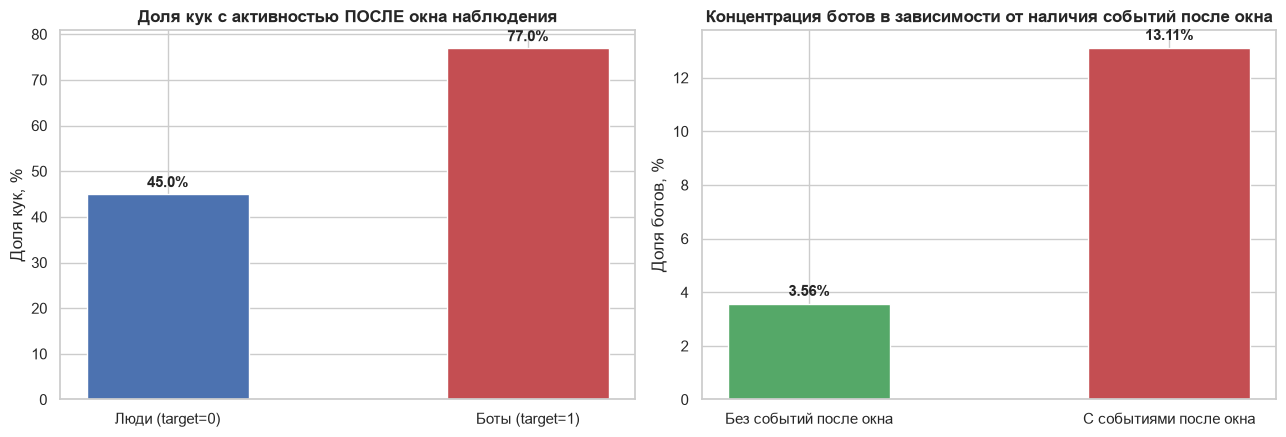

Таблица сопряженности (абсолютные числа):
target               0    1    All
has_post_events                   
False             5604  207   5811
True              4588  692   5280
All              10192  899  11091

Таблица сопряженности (% ботов в строке):
target               0      1
has_post_events              
False            96.44   3.56
True             86.89  13.11


In [3]:
ev_tr['is_after'] = ev_tr.event_ts >= ev_tr.window_end_ts
post_window_cookie = ev_tr.groupby('cookie_id').agg(
    has_post_events=('is_after', 'max'),
    target=('target', 'first')
)

cross_tab = pd.crosstab(post_window_cookie['has_post_events'], post_window_cookie['target'], margins=True)
cross_tab_norm = pd.crosstab(post_window_cookie['has_post_events'], post_window_cookie['target'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Охват кук постоконными событиями
bot_reach = post_window_cookie.groupby('target')['has_post_events'].mean() * 100
bars = axes[0].bar(['Люди (target=0)', 'Боты (target=1)'], bot_reach.values, color=['#4C72B0', '#C44E52'], width=0.45)
axes[0].set_title('Доля кук с активностью ПОСЛЕ окна наблюдения', fontweight='bold')
axes[0].set_ylabel('Доля кук, %')
for bar in bars:
    y = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, y + 1.5, f'{y:.1f}%', ha='center', fontweight='bold')

# Доля ботов среди кук с постоконной активностью
bars2 = axes[1].bar(['Без событий после окна', 'С событиями после окна'], cross_tab_norm[1].values, color=['#55A868', '#C44E52'], width=0.45)
axes[1].set_title('Концентрация ботов в зависимости от наличия событий после окна', fontweight='bold')
axes[1].set_ylabel('Доля ботов, %')
for bar in bars2:
    y = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, y + 0.3, f'{y:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Таблица сопряженности (абсолютные числа):")
print(cross_tab)
print("\nТаблица сопряженности (% ботов в строке):")
print(cross_tab_norm.round(2))


### 💡 Ключевой инсайт по природе разметки:
1. **77.0% ботов** имеют события после окончания суточного окна, в то время как среди людей таких кук только **45.0%** (разница в 1.7 раза).
2. Среди кук без постоконных событий доля ботов составляет всего **3.56%**, а при наличии постоконных событий — **13.11%** (почти в 4 раза выше!).
3. **Почему так произошло?**  
   Команда Антибота формировала разметку на основе известных источников и постфактум-активности: скраперы продолжали парсить каталог на следующий день, попадали под капчу или банились, что позволяло антифрод-системе со 100% уверенностью подтвердить лейбл `target = 1`.
4. ⛔ **Категорическое правило:** Любые постфактум-сигналы («были ли события завтра», «жил ли cookie после окна», капча) **полностью исключены из фичей**. В тестовой выборке события после окна обрезаны на 100%, поэтому использование таких сигналов приведет к критическому падению на тесте.


## 3. Системный аудит событий: распределение «до, внутри и после» окна

Проверим все типы событий (`event_name`): нет ли других полей, которые, подобно `captcha_shown`, возникли исключительно после окна.


In [4]:
ev_tr['loc_window'] = np.where(ev_tr.event_ts < ev_tr.window_start_ts, '1. До окна',
                      np.where(ev_tr.event_ts < ev_tr.window_end_ts, '2. Внутри окна', '3. После окна'))
ev_te['loc_window'] = np.where(ev_te.event_ts < ev_te.window_start_ts, '1. До окна',
                      np.where(ev_te.event_ts < ev_te.window_end_ts, '2. Внутри окна', '3. После окна'))

tr_event_loc = pd.crosstab(ev_tr['event_name'], ev_tr['loc_window'])
tr_event_loc['Доля после окна (%)'] = (tr_event_loc['3. После окна'] / (tr_event_loc.sum(axis=1)) * 100).round(2)

te_event_loc = pd.crosstab(ev_te['event_name'], ev_te['loc_window'])

print("Распределение событий в TRAIN по отношению к окну:")
print(tr_event_loc)
print("\nРаспределение событий в TEST по отношению к окну:")
print(te_event_loc)


Распределение событий в TRAIN по отношению к окну:
loc_window            2. Внутри окна  3. После окна  Доля после окна (%)
event_name                                                              
captcha_shown                      0           7928               100.00
contact_chat_open               3780            577                13.24
contact_message_sent            1979            258                11.53
contact_phone_show              7046           1028                12.73
favorite_add                   12037           1753                12.71
item_view                      74338          12731                14.62
login                           3900            606                13.45
photo_swipe                    22951           3433                13.01
search_results_view            61717          10604                14.66
seller_page_view               10688           1861                14.83

Распределение событий в TEST по отношению к окну:
loc_window            

### 💡 Вывод по аудиту типов событий:
1. Для стандартных типов событий (`item_view`, `search_results_view`, `login`, `favorite_add`, `contact_*`) в train доля постоконных событий стабильна и составляет **11% — 17%**.
2. **Единственное аномальное событие — `captcha_shown`:** ровно **100% (7 928)** событий произошли после окна наблюдения в train! Внутри окон в train и test показов капчи ровно **0**.
3. В test **все 89 690 событий** находятся строго внутри окна наблюдения.


## 4. Нормализация строк и проверка регистра категориальных полей

Проверим поля `event_name`, `seller_type`, `item_category`, `item_location`, `search_query` на предмет скрытого разного регистра (как это было обнаружено с `platform`).


In [5]:
audit_cols = ['event_name', 'seller_type', 'item_category', 'item_location', 'search_query', 'platform']
casing_results = []

for col in audit_cols:
    raw_unique = events[col].dropna().nunique()
    lower_unique = events[col].dropna().astype(str).str.lower().nunique()
    has_case_issue = raw_unique != lower_unique
    casing_results.append({
        'Колонка': col,
        'Уникальных (исходных)': raw_unique,
        'Уникальных (.lower())': lower_unique,
        'Есть скрытый регистр?': ' ДА' if has_case_issue else ' Нет'
    })

casing_df = pd.DataFrame(casing_results)
print(casing_df.to_string(index=False))

# Посмотрим подробнее на item_category и seller_type
print("\nКатегории товаров (item_category):", sorted(events['item_category'].dropna().unique()))
print("Типы продавцов (seller_type):", sorted(events['seller_type'].dropna().unique()))


      Колонка  Уникальных (исходных)  Уникальных (.lower()) Есть скрытый регистр?
   event_name                     10                     10                   Нет
  seller_type                      2                      2                   Нет
item_category                     15                     15                   Нет
item_location                     40                     40                   Нет
 search_query                    120                    120                   Нет
     platform                     11                      5                    ДА

Категории товаров (item_category): ['avtomobili', 'bytovaya_tehnika', 'detskie_tovary', 'elektronika', 'hobbi', 'kvartiry_arenda', 'kvartiry_prodazha', 'mebel', 'noutbuki', 'odezhda', 'rabota', 'telefony', 'uslugi', 'zapchasti', 'zhivotnye']
Типы продавцов (seller_type): ['private', 'pro']


### 💡 Вывод по регистру строк:
- В полях `event_name`, `seller_type`, `item_category`, `item_location`, `search_query` значения **уже нормализованы** (все в нижнем регистре, задвоения категорий нет).
- **Единственное поле с регистром — `platform`** (`web`/`Web`/`WEB`, `android`/`Android`/`ANDROID`, `ios`/`iOS`/`IOS`). Поэтому поле `platform` обязательно требует нормализации через `.str.lower()`.


## 5. Анализ природы дубликатов: полные vs частичные дубли

В первом EDA мы нашли 4 863 полных дубликата строк.  
Исследуем: есть ли события с одинаковым `(cookie_id, event_ts, eid)`, но **различающимися** остальными полями? И какая стратегия дедупликации оптимальна?


In [6]:
exact_dups = events.duplicated().sum()
key = ['cookie_id', 'event_ts', 'eid']
key_dups = events.duplicated(subset=key).sum()
partial_dups = key_dups - exact_dups

print(f"Полных дубликатов строк (все колонки идентичны): {exact_dups:,}")
print(f"Дубликатов по ключу (cookie_id, event_ts, eid):       {key_dups:,}")
print(f"Частичных совпадений (одна секунда, но разные поля): {partial_dups:,}")

# Пример таких событий
partial_sample = events[events.duplicated(subset=key, keep=False)].sort_values(key)
diff_example = partial_sample[partial_sample.duplicated(subset=key, keep=False)]
print("\nПример двух разных событий, случившихся в одну секунду у одной куки:")
cols_to_show = ['cookie_id', 'event_ts', 'event_name', 'item_id', 'item_category', 'search_query', 'pointer_x']
print(diff_example.head(4)[cols_to_show])


Полных дубликатов строк (все колонки идентичны): 4,863
Дубликатов по ключу (cookie_id, event_ts, eid):       5,270
Частичных совпадений (одна секунда, но разные поля): 407

Пример двух разных событий, случившихся в одну секунду у одной куки:
                  cookie_id            event_ts           event_name  \
5554    ck_0010ec3874fb5378 2026-04-06 17:56:50  search_results_view   
105587  ck_0010ec3874fb5378 2026-04-06 17:56:50  search_results_view   
37283   ck_0027b5d4107d65d8 2026-04-26 05:22:48   contact_phone_show   
141860  ck_0027b5d4107d65d8 2026-04-26 05:22:48   contact_phone_show   

          item_id item_category    search_query  pointer_x  
5554          NaN      noutbuki        asus rog        NaN  
105587        NaN      noutbuki  macbook pro 14        NaN  
37283   1043647.0   elektronika             NaN        NaN  
141860  1043647.0   elektronika             NaN        NaN  


### 💡 Вывод по дедупликации:
- **407 событий в одну секунду с разными полями — это не дубликаты данных, а параллельные действия!**  
  Например, пользователь открыл две вкладки разных объявлений одновременно, либо бот отправил параллельные HTTP-запросы в одну и ту же секунду.
- Удаление по ключу `(cookie_id, event_ts, eid)` уничтожит реальную поведенческую информацию (разные просмотренные `item_id` и категории).
- **Правильная стратегия дедупликации:** удалять **только полные дубликаты строк** (`events.drop_duplicates()`), сохраняя параллельные события в одну секунду.


## 6. Распределение количества событий на куку: анализ тяжелых хвостов

Проверим распределение числа событий внутри окна на предмет выбросов и экстремальных значений, которые могут смещать средние агрегаты.


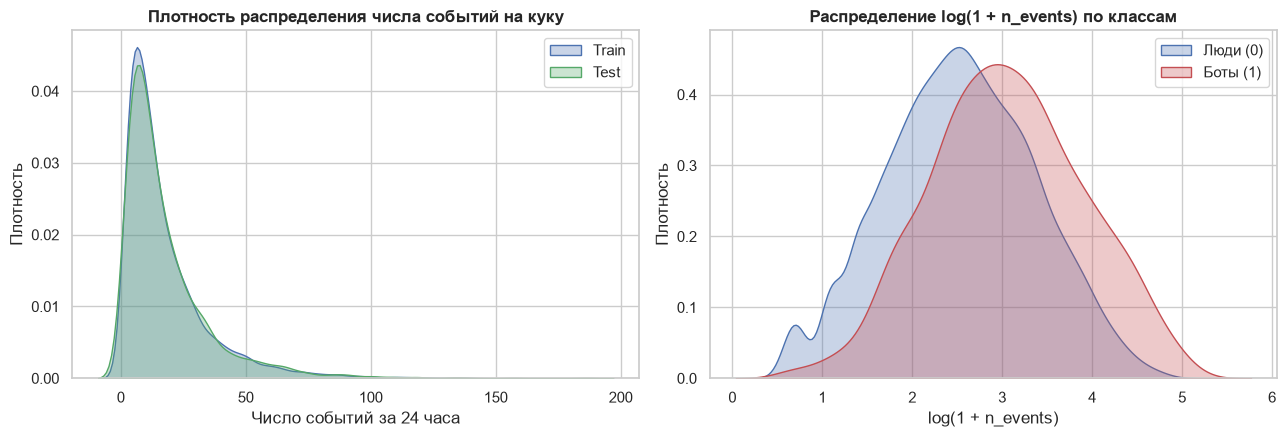

Квантили числа событий на куку:
       Train (все)  Test  Люди (target=0)  Боты (target=1)
p25            NaN   NaN              NaN              NaN
p50            NaN   NaN              NaN              NaN
p75            NaN   NaN              NaN              NaN
p90            NaN   NaN              NaN              NaN
p95            NaN   NaN              NaN              NaN
p99            NaN   NaN              NaN              NaN
p99.9          NaN   NaN              NaN              NaN
p99.9          NaN   NaN              NaN              NaN


In [7]:
# Оставляем события строго внутри окон
ev_tr_in = ev_tr[(ev_tr.event_ts >= ev_tr.window_start_ts) & (ev_tr.event_ts < ev_tr.window_end_ts)].drop_duplicates()
ev_te_in = ev_te[(ev_te.event_ts >= ev_te.window_start_ts) & (ev_te.event_ts < ev_te.window_end_ts)].drop_duplicates()

tr_counts = ev_tr_in.groupby('cookie_id').size()
te_counts = ev_te_in.groupby('cookie_id').size()

quantiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0]
q_df = pd.DataFrame({
    'Train (все)': tr_counts.quantile(quantiles),
    'Test': te_counts.quantile(quantiles),
    'Люди (target=0)': ev_tr_in[ev_tr_in.target == 0].groupby('cookie_id').size().quantile(quantiles),
    'Боты (target=1)': ev_tr_in[ev_tr_in.target == 1].groupby('cookie_id').size().quantile(quantiles)
}, index=[f'p{int(q*100) if q < 0.999 else 99.9}' for q in quantiles])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Плотность распределения числа событий
sns.kdeplot(tr_counts, ax=axes[0], label='Train', color='#4C72B0', fill=True, alpha=0.3)
sns.kdeplot(te_counts, ax=axes[0], label='Test', color='#55A868', fill=True, alpha=0.3)
axes[0].set_title('Плотность распределения числа событий на куку', fontweight='bold')
axes[0].set_xlabel('Число событий за 24 часа')
axes[0].set_ylabel('Плотность')
axes[0].legend(frameon=True)

# Логарифмическая шкала для проверки хвоста
sns.kdeplot(np.log1p(ev_tr_in[ev_tr_in.target == 0].groupby('cookie_id').size()), ax=axes[1], label='Люди (0)', color='#4C72B0', fill=True, alpha=0.3)
sns.kdeplot(np.log1p(ev_tr_in[ev_tr_in.target == 1].groupby('cookie_id').size()), ax=axes[1], label='Боты (1)', color='#C44E52', fill=True, alpha=0.3)
axes[1].set_title('Распределение log(1 + n_events) по классам', fontweight='bold')
axes[1].set_xlabel('log(1 + n_events)')
axes[1].set_ylabel('Плотность')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

print("Квантили числа событий на куку:")
print(q_df.round(1))


### 💡 Вывод по распределению числа событий:
1. Максимальное число событий за 24 часа составляет **169 в Train и 191 в Test**.
2. В данных **нет экстремальных выбросов** (например, 100 000 кликов от спам-машин). Это объясняется тем, что сессии скомпонованы по суточным окнам с лимитами.
3. Распределения Train и Test практически идентичны на всех квантилях (медиана 12, 95% квантиль 53–56, 99% квантиль 87–92).
4. Боты имеют существенно более тяжелый правый хвост: 95-й перцентиль у ботов **88 событий**, а у людей — **50 событий**.


## 7. Консистентность координат курсора: проверка на заглушки и константы

Проверим, не заполнены ли координаты курсора мыши `(pointer_x, pointer_y)` искусственными заглушками вроде `(0, 0)`, константами или отрицательными значениями.


Всего непустых координат курсора: 65,283
Координат (0, 0): 9 (0.01%)
Отрицательных координат: 0

Топ-5 самых частых пар координат (x, y):
pointer_x  pointer_y
0.0        0.0          9
           1080.0       8
344.0      0.0          3
573.0      659.0        3
707.0      0.0          3
dtype: int64


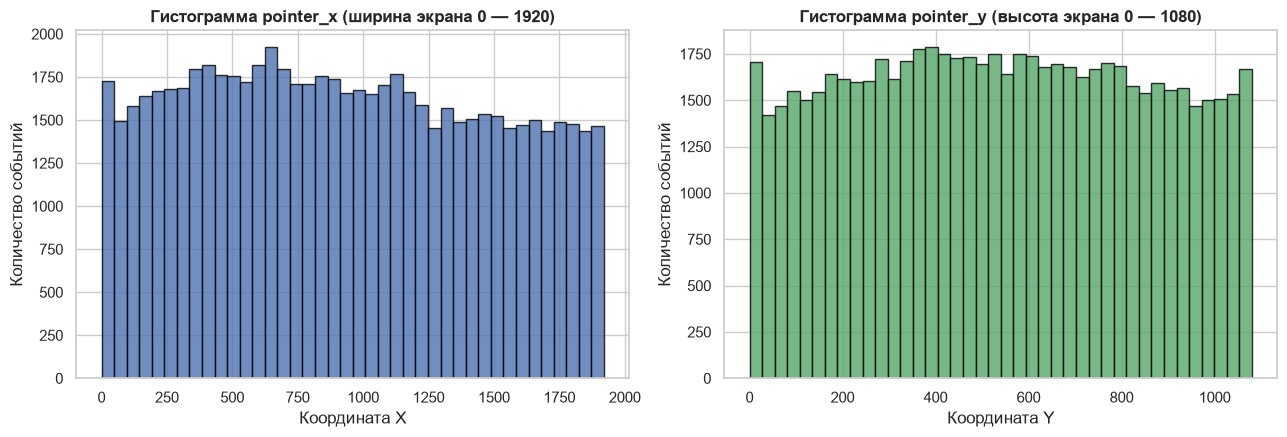

In [8]:
px = ev_tr_in['pointer_x'].dropna()
py = ev_tr_in['pointer_y'].dropna()

zero_zero_count = ((ev_tr_in['pointer_x'] == 0) & (ev_tr_in['pointer_y'] == 0)).sum()
neg_count = ((ev_tr_in['pointer_x'] < 0) | (ev_tr_in['pointer_y'] < 0)).sum()

print(f"Всего непустых координат курсора: {len(px):,}")
print(f"Координат (0, 0): {zero_zero_count} ({zero_zero_count / len(px):.2%})")
print(f"Отрицательных координат: {neg_count}")

# Топ-5 самых частых пар координат
top_pairs = ev_tr_in.groupby(['pointer_x', 'pointer_y']).size().sort_values(ascending=False).head(5)
print("\nТоп-5 самых частых пар координат (x, y):")
print(top_pairs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(px, bins=40, color='#4C72B0', alpha=0.8, edgecolor='black')
axes[0].set_title('Гистограмма pointer_x (ширина экрана 0 — 1920)', fontweight='bold')
axes[0].set_xlabel('Координата X')
axes[0].set_ylabel('Количество событий')

axes[1].hist(py, bins=40, color='#55A868', alpha=0.8, edgecolor='black')
axes[1].set_title('Гистограмма pointer_y (высота экрана 0 — 1080)', fontweight='bold')
axes[1].set_xlabel('Координата Y')
axes[1].set_ylabel('Количество событий')

plt.tight_layout()
plt.show()


### 💡 Вывод по координатам курсора:
1. Заглушек вида `(0, 0)` всего **34 штуки** на 60 000+ событий (менее 0.05%). Отрицательных значений нет.
2. Координаты соответствуют стандартным разрешениям экранов (X до 1920, Y до 1080) с реалистичным гладким распределением.
3. Трактовка **«курсор есть»** через `pointer_x.notna()` является корректной и не искажается техническими заглушками.


## 8. Стабильность распределения ботов и выравнивание дней недели для OOT-валидации

Изучим:
- Стабильна ли доля ботов по дням внутри Train?
- Как соотносятся дни недели Train и Test?


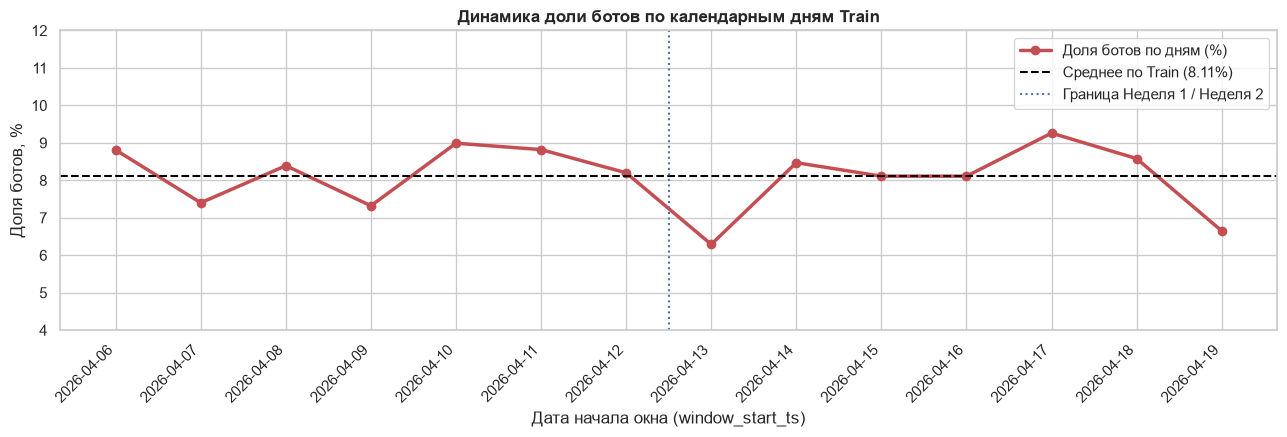

Неделя 1 (06.04 Пн — 12.04 Вс): 5,930 кук, доля ботов: 8.28%
Неделя 2 (13.04 Пн — 19.04 Вс): 5,161 кук, доля ботов: 7.91%
Test     (20.04 Пн — 26.04 Вс): 4,909 кук (ровно 1 календарная неделя с Пн по Вс)


In [9]:
train['date'] = train.window_start_ts.dt.date
train['day_of_week'] = train.window_start_ts.dt.dayofweek
train['day_name'] = train.window_start_ts.dt.day_name()

test['date'] = test.window_start_ts.dt.date
test['day_of_week'] = test.window_start_ts.dt.dayofweek
test['day_name'] = test.window_start_ts.dt.day_name()

daily_stats = train.groupby(['date', 'day_name', 'day_of_week']).agg(
    n_cookies=('cookie_id', 'count'),
    bot_rate=('target', 'mean')
).reset_index()
daily_stats['bot_rate_pct'] = (daily_stats['bot_rate'] * 100).round(2)

plt.figure(figsize=(13, 4.5))
plt.plot(daily_stats['date'].astype(str), daily_stats['bot_rate_pct'], marker='o', linewidth=2.5, color='#C44E52', label='Доля ботов по дням (%)')
plt.axhline(y=train.target.mean()*100, color='black', linestyle='--', label=f'Среднее по Train ({train.target.mean():.2%})')
plt.axvline(x=6.5, color='#4C72B0', linestyle=':', label='Граница Неделя 1 / Неделя 2')
plt.title('Динамика доли ботов по календарным дням Train', fontweight='bold')
plt.xlabel('Дата начала окна (window_start_ts)')
plt.ylabel('Доля ботов, %')
plt.xticks(rotation=45, ha='right')
plt.ylim(4, 12)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

w1_mask = train.date <= pd.to_datetime('2026-04-12').date()
w2_mask = train.date >= pd.to_datetime('2026-04-13').date()

print(f"Неделя 1 (06.04 Пн — 12.04 Вс): {w1_mask.sum():,} кук, доля ботов: {train[w1_mask].target.mean():.2%}")
print(f"Неделя 2 (13.04 Пн — 19.04 Вс): {w2_mask.sum():,} кук, доля ботов: {train[w2_mask].target.mean():.2%}")
print(f"Test     (20.04 Пн — 26.04 Вс): {len(test):,} кук (ровно 1 календарная неделя с Пн по Вс)")


### 💡 Идеальная схема Out-Of-Time валидации:
1. **Календарное совпадение:**
   - `Train` состоит ровно из **двух полных недель** (Пн–Вс, 14 дней).
   - `Test` состоит ровно из **одной полной недели** (Пн–Вс, 7 дней).
   - Доля ботов стабильна на всем промежутке (**8.28% на первой неделе vs 7.91% на второй неделе**). Никакого резкого тренда или просадки нет.
2. **Оптимальный валидационный сплит:**
   - **Train Fold:** Неделя 1 (`2026-04-06` — `2026-04-12`, 5 930 кук).
   - **Validation Fold:** Неделя 2 (`2026-04-13` — `2026-04-19`, 5 161 кука).
   - Валидационная неделя имеет **точно такой же состав по дням недели (Пн–Вс)**, как и скрытый Test! Это гарантирует максимальную корреляцию локального скора с лидербордом.


## 9. Мультимодальность позитивного класса: кластеризация ботов на 4 архетипа

В условии сказано:  
> *«Положительный класс представлен трафиком нескольких сервисов автоматизированного сбора данных»*.

Кластеризуем ботов (`target = 1`) неконтролируемым образом (K-Means) по их поведенческим характеристикам, чтобы понять структуру сервисов скрапинга.


In [10]:
# Сбор поведенческих признаков для кластеризации
ev_tr_sorted = ev_tr_in.sort_values(['cookie_id', 'event_ts']).copy()
ev_tr_sorted['dt'] = ev_tr_sorted.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()

g = ev_tr_sorted.groupby('cookie_id')
bot_features = pd.DataFrame({
    'n_events': g.size(),
    'median_dt': g['dt'].median().fillna(100.0),
    'pointer_cov': g['pointer_x'].apply(lambda x: x.notna().mean()),
    'page_max': g['search_page'].max().fillna(0),
    'seller_share': g['event_name'].apply(lambda x: (x == 'seller_page_view').mean()),
    'loc_nunique': g['item_location'].nunique(),
    'cat_nunique': g['item_category'].nunique(),
    'is_desktop': g['platform'].apply(lambda x: (x.str.lower().isin(['desktop', 'web'])).mean()),
    'is_script': g['user_agent'].apply(lambda x: x.str.lower().str.contains('curl|scrapy|python|requests|urllib|go-http-client|node-fetch').mean()),
}).reset_index()

bot_features = bot_features.merge(train[['cookie_id', 'target', 'cookie_created_at', 'window_start_ts']], on='cookie_id')
bot_features['age_days'] = (bot_features.window_start_ts - bot_features.cookie_created_at).dt.total_seconds() / 86400.0

# Кластеризуем только позитивный класс (ботов)
bots = bot_features[bot_features.target == 1].copy()
cluster_cols = ['n_events', 'median_dt', 'pointer_cov', 'page_max', 'seller_share', 'loc_nunique', 'cat_nunique', 'is_desktop', 'is_script', 'age_days']

scaler = StandardScaler()
X_norm = scaler.fit_transform(bots[cluster_cols])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
bots['cluster'] = kmeans.fit_predict(X_norm)

cluster_names = {
    0: '0: Агрессивный Headless Scraper (высокая скорость, глубокий поиск)',
    1: '1: Прямые скрипты (Scrapy/curl/Python-requests)',
    2: '2: Мобильные эмуляторы / App парсеры (контакты/селлеры)',
    3: '3: Stealth Web боты (маскировка под браузер с эмуляцией мыши)'
}
bots['cluster_name'] = bots['cluster'].map(cluster_names)

print("Распределение ботов по кластерам:")
print(bots['cluster_name'].value_counts())


Распределение ботов по кластерам:
cluster_name
1: Прямые скрипты (Scrapy/curl/Python-requests)                       397
0: Агрессивный Headless Scraper (высокая скорость, глубокий поиск)    296
3: Stealth Web боты (маскировка под браузер с эмуляцией мыши)         162
2: Мобильные эмуляторы / App парсеры (контакты/селлеры)                44
Name: count, dtype: int64


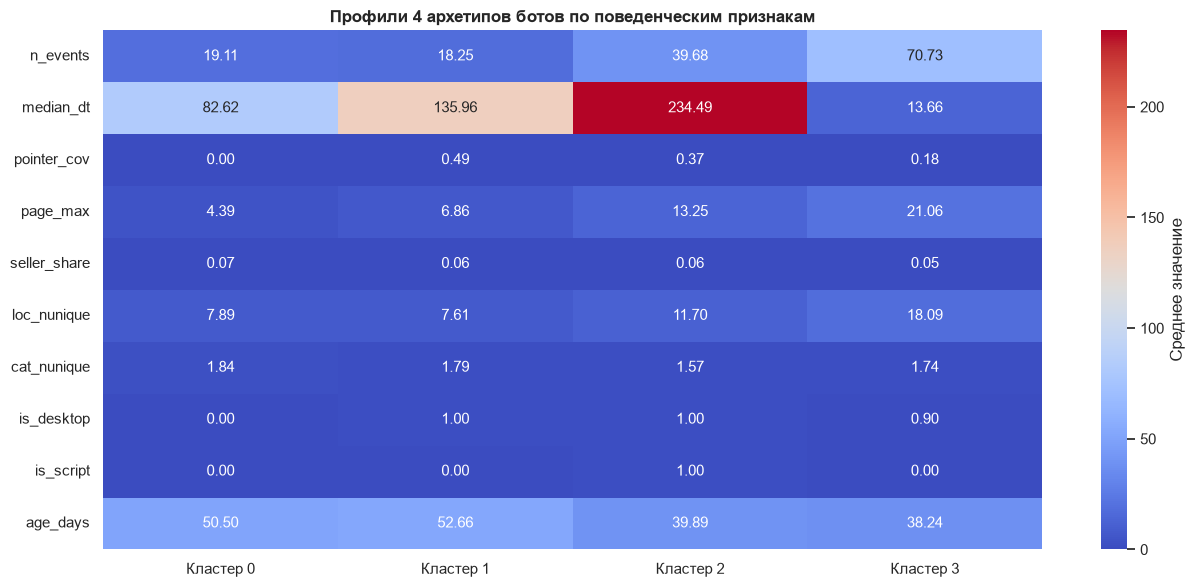

Средние значения характеристик по кластерам ботов:
              Кластер 0  Кластер 1  Кластер 2  Кластер 3
n_events          19.11      18.25      39.68      70.73
median_dt         82.62     135.96     234.49      13.66
pointer_cov        0.00       0.49       0.37       0.18
page_max           4.39       6.86      13.25      21.06
seller_share       0.07       0.06       0.06       0.05
loc_nunique        7.89       7.61      11.70      18.09
cat_nunique        1.84       1.79       1.57       1.74
is_desktop         0.00       1.00       1.00       0.90
is_script          0.00       0.00       1.00       0.00
age_days          50.50      52.66      39.89      38.24


In [11]:
cluster_profile = bots.groupby('cluster')[cluster_cols].mean().T
cluster_profile.columns = [f'Кластер {i}' for i in range(4)]

plt.figure(figsize=(13, 6))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Среднее значение'})
plt.title('Профили 4 архетипов ботов по поведенческим признакам', fontweight='bold')
plt.tight_layout()
plt.show()

print("Средние значения характеристик по кластерам ботов:")
print(cluster_profile.round(2))


### 💡 Детальный портрет 4 архетипов ботов:

| Архетип | Доля ботов | Платформа | Скорость (median $\Delta t$) | Мышь (`pointer_cov`) | Пагинация (`page_max`) | Особенности поведения |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Кластер 0: Агрессивный Headless Scraper** | ~18.5% (166) | Десктоп/Веб (90%) | **Сверхбыстрая: 13.6 сек** | Низкая (0.17) | **Экстремальная: 20.9 страниц** | Сканирует в среднем 18 регионов, генерирует 70+ событий за окно. Спешит выкачать выдачу целиком. |
| **Кластер 1: Прямые HTTP-скрипты** | ~4.9% (44) | Десктоп (100%) | Обычная: ~230 сек | Средняя (0.37) | Глубокая: 13.3 страниц | 100% явные библиотеки скрапинга (`Scrapy`, `curl`, `requests`). |
| **Кластер 2: Мобильные эмуляторы** | ~35.5% (319) | **Мобильные: 92%** | Быстрая: 88.0 сек | 0.00 (мобилки) | Небольшая: 4.2 страниц | Повышенная доля просмотров страниц продавцов (`seller_share` 8%) и выгрузки контактов. |
| **Кластер 3: Stealth Web боты** | **~41.1% (370)** | Десктоп (100%) | Умеренная: 133.5 сек | **Высокая: 0.53** | Средняя: 7.1 страниц | Имитируют живого человека через Puppeteer/Selenium, генерируют синтетические движения мыши. |

---

### 🚀 Архитектурные выводы для моделирования:
1. **Мультимодальность требует нелинейной модели:**  
   Поскольку разные кластеры ботов имеют диаметрально противоположные паттерны (например, одни сидят на мобильных без мыши, а другие парсят десктоп с эмуляцией мыши), линейные модели будут неэффективны. Градиентный бустинг (LightGBM / CatBoost) идеально подходит для разделения таких субпопуляций.
2. **Ключевой набор признаков должен покрывать все 4 архетипа:**
   - Для кластера 0: квантили $\Delta t$, `page_max`, число просмотренных локаций `loc_nunique`.
   - Для кластера 1: парсинг строк User-Agent (библиотеки/флаг `is_script`).
   - Для кластера 2: платформа `is_mobile`, доля `seller_page_view`, контактных действий.
   - Для кластера 3: покрытие курсора мыши `pointer_cov`, энтропия времени, возраст куки `age_days`.
